In [93]:
import os
import glob
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pycocotools import mask as mask_utils

# Visualize

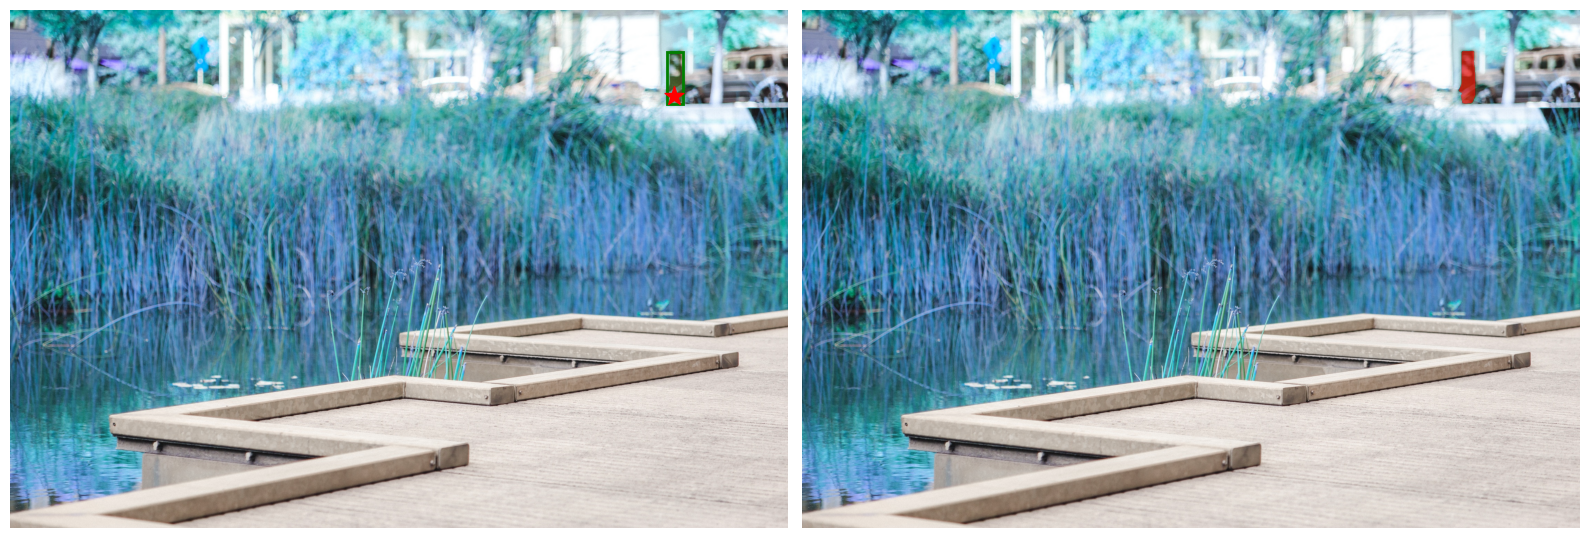

In [92]:
data_path = "/home/cc/training-data/Raw-Data/extracted/"

with open(data_path + 'sa_9932.json', 'r') as f1:
    json1 = json.load(f1)

img1 = cv2.imread(data_path + 'sa_9932.jpg')

ann = json1["annotations"][1]
bbox = ann["bbox"]              # Format: [x_min, y_min, width, height]
point = ann["point_coords"][0]  # Format: [x, y]
segmentation = ann["segmentation"]
segmentation['counts'] = segmentation['counts'].encode('utf-8')

binary_mask = mask_utils.decode(segmentation)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

ax1 = axes[0]
ax1.imshow(img1)

rect = patches.Rectangle(
    (bbox[0], bbox[1]), bbox[2], bbox[3],
    linewidth=2, edgecolor='green', facecolor='none'
)
ax1.add_patch(rect)

ax1.scatter(point[0], point[1], color='red', marker='*', s=200)
ax1.axis('off')

ax2 = axes[1]
ax2.imshow(img1)

mask_2d = binary_mask.squeeze()
rgba_mask = np.zeros((mask_2d.shape[0], mask_2d.shape[1], 4), dtype=np.float32)
rgba_mask[mask_2d == 1] = [1.0, 0.0, 0.0, 0.6]
ax2.imshow(rgba_mask)

ax2.axis('off')

plt.tight_layout()
plt.show()

# Save examples

In [94]:
data_path = "/home/cc/training-data/Raw-Data/extracted/"
output_dir = "./"

json_files = glob.glob(os.path.join(data_path, "*.json"))[:5]

for json_file in json_files:
    base_name = os.path.basename(json_file).replace('.json', '')
    img_path = os.path.join(data_path, f"{base_name}.jpg")
    
    with open(json_file, 'r') as f:
        json_data = json.load(f)
        
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    annotations = json_data.get("annotations", [])[:2]
    
    for ann_idx, ann in enumerate(annotations):
        bbox = ann["bbox"]              
        point = ann["point_coords"][0]  
        segmentation = ann["segmentation"]
        
        if isinstance(segmentation['counts'], str):
            segmentation['counts'] = segmentation['counts'].encode('utf-8')
            
        binary_mask = mask_utils.decode(segmentation)
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
        ax1 = axes[0]
        ax1.imshow(img_rgb)
        
        rect = patches.Rectangle(
            (bbox[0], bbox[1]), bbox[2], bbox[3],
            linewidth=2, edgecolor='green', facecolor='none'
        )
        ax1.add_patch(rect)
        ax1.scatter(point[0], point[1], color='red', marker='*', s=200)
        ax1.axis('off')
        
        ax2 = axes[1]
        ax2.imshow(img_rgb)
        
        mask_2d = binary_mask.squeeze()
        rgba_mask = np.zeros((mask_2d.shape[0], mask_2d.shape[1], 4), dtype=np.float32)
        rgba_mask[mask_2d == 1] = [1.0, 0.0, 0.0, 0.6] 
        ax2.imshow(rgba_mask)
        ax2.axis('off')
        
        plt.tight_layout()
        
        save_name = f"{base_name}_ann{ann_idx}.png"
        save_path = os.path.join(output_dir, save_name)
        
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        
        plt.close(fig)